<a href="https://colab.research.google.com/github/navanithav87-beep/client_sphere_crm/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])
model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=10000, verbose=0)
loss, accuracy = model.evaluate(X, y)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy*100:.2f}%")
predictions = model.predict(X)
print("Predictions:")
for i in range(len(predictions)):
  print(f"Input: {X[i]}, Prediction: {predictions[i][0]:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 1.0000 - loss: 7.1078e-05
Loss: 0.0001, Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predictions:
Input: [0 0], Prediction: 0.0001
Input: [0 1], Prediction: 0.9999
Input: [1 0], Prediction: 0.9999
Input: [1 1], Prediction: 0.0001


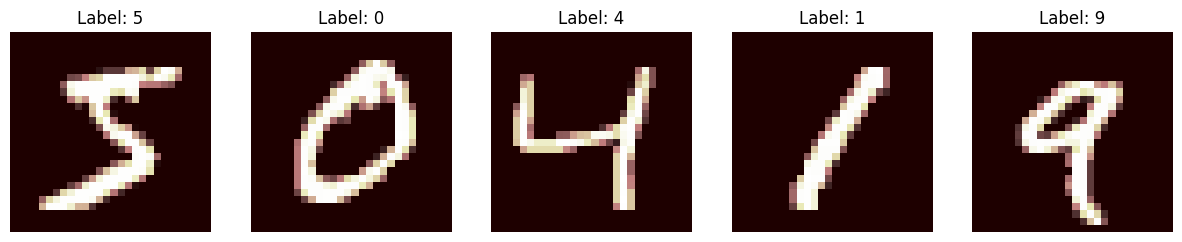

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

num_samples_to_visualize = 5
plt.figure(figsize=(15, 3))
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.show()

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy}")

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.9177 - loss: 0.2649 - val_accuracy: 0.9800 - val_loss: 0.0630
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9725 - loss: 0.0921 - val_accuracy: 0.9892 - val_loss: 0.0399
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9795 - loss: 0.0677 - val_accuracy: 0.9900 - val_loss: 0.0352
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.9836 - loss: 0.0537 - val_accuracy: 0.9895 - val_loss: 0.0360
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.9860 - loss: 0.0465 - val_accuracy: 0.9898 - val_loss: 0.0355
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9876 - loss: 0.0394 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.9895 - loss: 0.0344 - val_accuracy: 0.9923 - val_loss: 0.0288
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.9901 - loss: 0.0307 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9929 - loss: 0.0282
Test accuracy: 0.992900013923645
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


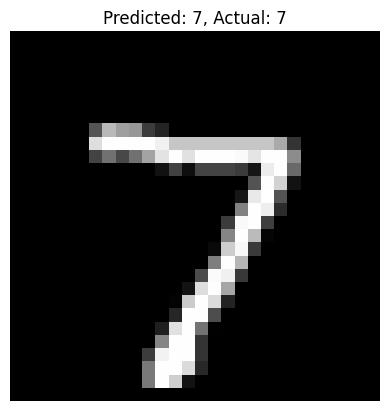

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy}")

index = 0
sample_image = x_test[index]
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {np.argmax(y_test[index])}")
plt.axis('off')
plt.show()